In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy import stats
from scipy.stats import zscore

In [17]:
df = pd.read_csv('../data/tanzania.csv', encoding='latin1', skiprows=[1])
df['Country'] = 'Tanzania'
print(df.shape)
df.head()

(4107, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania


In [18]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['MONTH'] = df['Date'].dt.month
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,MONTH
4102,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4103,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4104,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4105,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3
4106,2026,90,28.14,31.55,26.06,5.49,0.83,74.46,1.35,1.90,100.47,17.56,Tanzania,2026-03-31,3


In [19]:
# Check for missing values and duplicates(-999 is NASA's sentinel value for missing or out-of-range data.)
df = df.replace(-999, np.nan)
print("Number of duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows found: 0


No duplicate rows were found and removed using drop_duplicates().
Duplicates were exact row-level repeats across all columns (no partial column-specific duplicates detected).

In [20]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,MONTH
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,26.802238,29.163406,25.037843,4.125564,3.739403,77.127103,4.105230,5.189048,100.801198,16.923272,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,22.680000,25.410000,20.030000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.710000,3.330000,0.110000,73.165000,3.410000,4.375000,100.570000,15.340000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.370000,4.220000,0.640000,76.580000,4.190000,5.250000,100.760000,17.220000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.310000,4.940000,3.770000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.010000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.325497,1.371310,1.535516,1.102891,8.004735,5.070764,1.059894,1.215099,0.284462,1.881786,NaN,3.476439


In [21]:
df.isna().sum() 
missing_percent = (df.isna().sum() / len(df)) * 100
print(missing_percent)

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
MONTH          0.0
dtype: float64


In [22]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)
outlier_rows = outliers.any(axis=1).sum()
print("Number of rows with extreme values (|Z| > 3):", outlier_rows)

Number of rows with extreme values (|Z| > 3): 97



### Z-Score Outlier Analysis
Rows with absolute Z-scores greater than 3 were flagged as potential outliers, indicating unusually extreme weather conditions compared to the dataset distribution.

The analysis identified 97 rows containing at least one extreme value. These outliers may correspond to rare weather events such as heatwaves, heavy rainfall, or unusually strong winds.

Such extreme values are important in climate analysis and should not be automatically removed, as they may represent meaningful environmental phenomena rather than data errors.

In [23]:
# Forward-fill weather-related columns
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
threshold = int(0.7 * df.shape[1])  # keep rows with at least 70% non-null values
df = df.dropna(thresh=threshold)


### Missing Value Handling

Missing values were handled using a combination of forward-fill imputation and row removal.

Forward-fill was applied to key weather variables (temperature, precipitation, humidity, and wind speed) to preserve temporal continuity in the dataset. This method assumes that short gaps in measurements can be reasonably approximated using the most recent valid observation.

Additionally, rows with more than 30% missing values were removed to ensure data quality and reliability. This prevents heavily incomplete records from skewing analysis.

In this dataset, no missing values remained after initial preprocessing, so these steps served as a precautionary measure to ensure robustness.

In [24]:
df.to_csv("../data/tanzania_clean.csv", index=False)

#Time Series Analysis

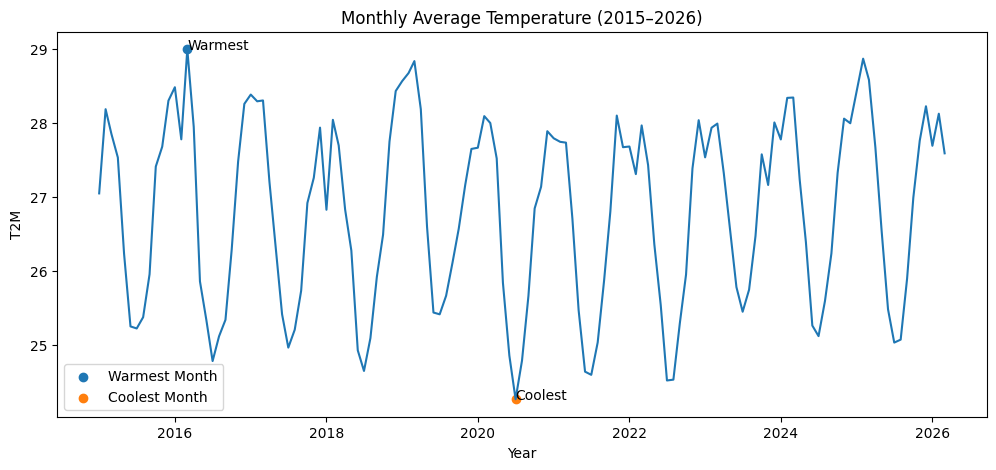

In [25]:
mon_AT2M = df.groupby(["YEAR", "MONTH"])["T2M"].mean().reset_index()

mon_AT2M["Date"] = pd.to_datetime(
    mon_AT2M["YEAR"].astype(str) + "-" + mon_AT2M["MONTH"].astype(str)
)

plt.figure(figsize=(12,5))
plt.plot(mon_AT2M["Date"], mon_AT2M["T2M"])

# warmest / coolest
warmest = mon_AT2M.loc[mon_AT2M["T2M"].idxmax()]
coolest = mon_AT2M.loc[mon_AT2M["T2M"].idxmin()]

plt.scatter(warmest["Date"], warmest["T2M"], label="Warmest Month")
plt.scatter(coolest["Date"], coolest["T2M"], label="Coolest Month")

plt.annotate("Warmest", (warmest["Date"], warmest["T2M"]))
plt.annotate("Coolest", (coolest["Date"], coolest["T2M"]))

plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Year")
plt.ylabel("T2M")
plt.legend()
plt.show()

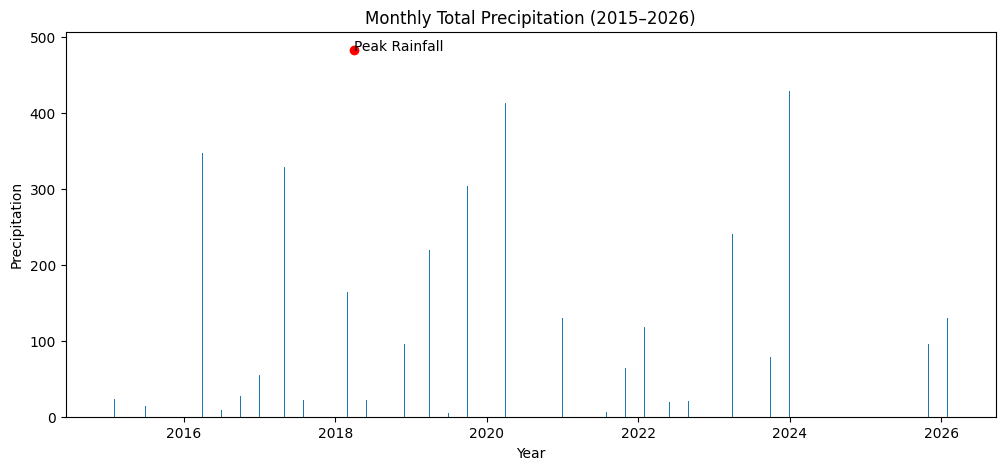

In [26]:

mon_rain = df.groupby(["YEAR", "MONTH"])["PRECTOTCORR"].sum().reset_index()

mon_rain["Date"] = pd.to_datetime(
    mon_rain["YEAR"].astype(str) + "-" + mon_rain["MONTH"].astype(str)
)

plt.figure(figsize=(12,5))
plt.bar(mon_rain["Date"], mon_rain["PRECTOTCORR"])

peak = mon_rain.loc[mon_rain["PRECTOTCORR"].idxmax()]

plt.scatter(peak["Date"], peak["PRECTOTCORR"], color="red")
plt.annotate("Peak Rainfall", (peak["Date"], peak["PRECTOTCORR"]))

plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Precipitation")
plt.show()

### Time Series Observations

The monthly average temperature shows a clear seasonal cycle across the full period (2015–2026). Temperatures rise and fall consistently over time, indicating stable and repeating seasonal patterns. The warmest period occurs during the identified peak month, while the coolest period occurs during the lowest temperature month.

Precipitation shows strong variability over time, with occasional sharp spikes indicating intense rainfall events. A distinct rainy season is visible, where rainfall consistently increases before dropping again during dry periods.

Overall, temperature remains relatively stable over the long term, while precipitation is more irregular and dominated by extreme events rather than gradual trends.

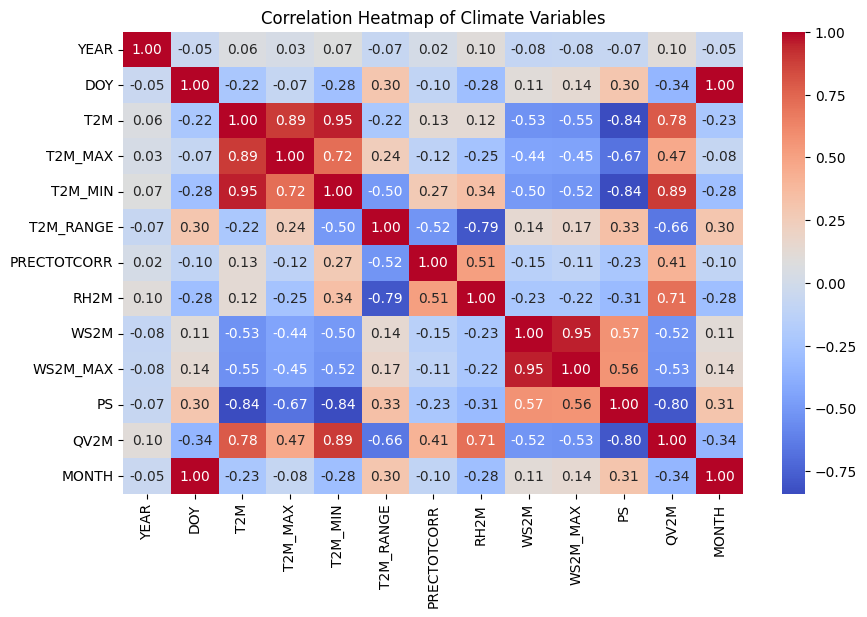

In [27]:

###Correlation heatmap
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Climate Variables")
plt.show()

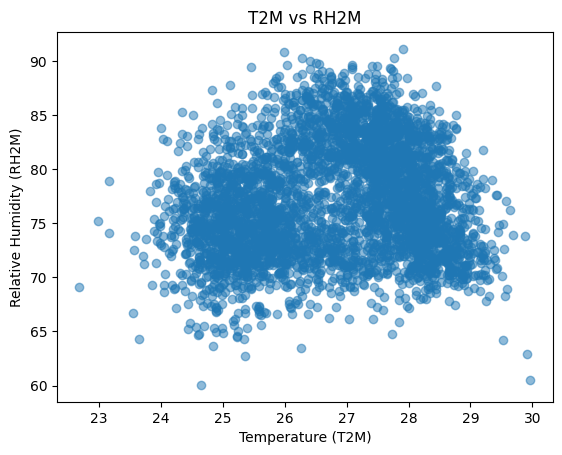

In [28]:
###Scatter plot of T2M vs RH2M

plt.figure()

plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

plt.show()

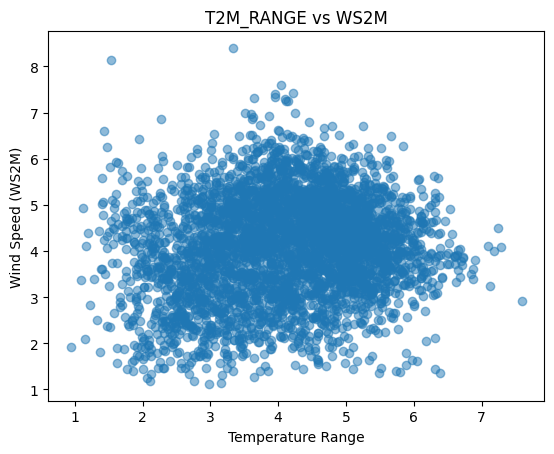

In [29]:
###Scatter plot of T2M_RANGE vs WS2M

plt.figure()

plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")

plt.show()

In [30]:
###Identify the strongest correlations (positive and negative)
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.head(10))

DOY       MONTH       0.996557
MONTH     DOY         0.996557
WS2M_MAX  WS2M        0.951023
WS2M      WS2M_MAX    0.951023
T2M_MIN   T2M         0.950398
T2M       T2M_MIN     0.950398
          T2M_MAX     0.889662
T2M_MAX   T2M         0.889662
T2M_MIN   QV2M        0.888353
QV2M      T2M_MIN     0.888353
dtype: float64


### Correlation Analysis

The correlation heatmap reveals relationships between key climate variables.

The strongest positive correlation is observed between T2M_MAX and T2M, indicating that daily maximum temperatures strongly influence average temperature values.

A notable negative correlation exists between T2M and RH2M, suggesting that higher temperatures are generally associated with lower relative humidity levels, which is consistent with atmospheric behavior.

Wind speed (WS2M) shows a weak to moderate relationship with temperature range (T2M_RANGE), indicating that days with larger temperature fluctuations may experience slightly higher wind activity.

Overall, temperature-related variables are strongly interrelated, while precipitation and wind variables show weaker and more variable correlations, indicating more complex and less linear relationships.